In [1]:
# Parameters — override these to run on a different dataset
DATASET_PATH = "../top100/top100_measures.jsonl"
DATASET_NAME = "Top100"
RAMA_FIELD = "rama3"  # rama3 for top100/top500, rama_category for top8000/top2018

In [2]:
import json
import math
import warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from collections import Counter
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 9,
    "axes.titlesize": 11,
    "figure.facecolor": "white",
})

In [3]:
# Load dataset and display title
with open(DATASET_PATH) as f:
    records = [json.loads(line) for line in f]

display(Markdown(f"""# {DATASET_NAME} Dataset — Geometric Analysis

**Residues:** {len(records):,} | **Source:** {DATASET_PATH.split('/')[-1]}
| **Generated by:** pydangle-biopython v0.5.1
"""))

# Top100 Dataset — Geometric Analysis

**Residues:** 17,434 | **Source:** top100_measures.jsonl
| **Generated by:** pydangle-biopython v0.5.1


In [4]:
# Extract angle arrays
def extract(field):
    return np.array([r[field] for r in records if r.get(field) is not None])

phi = extract("phi")
psi = extract("psi")
omega = extract("omega")
tau = extract("tau")

chi_fields = ["chi1", "chi2", "chi3", "chi4"]
chi = {f: extract(f) for f in chi_fields}
chi = {f: v for f, v in chi.items() if len(v) > 0}

# Rama categories
rama = np.array([r.get("rama_category", "Unknown") for r in records])

print(f"phi: {len(phi):,}  psi: {len(psi):,}  omega: {len(omega):,}  tau: {len(tau):,}")
for f, v in chi.items():
    print(f"{f}: {len(v):,}", end="  ")
print()

phi: 17,218  psi: 17,218  omega: 17,218  tau: 17,434
chi1: 14,380  chi2: 10,616  chi3: 6,441  chi4: 3,099  


## Amino Acid Composition

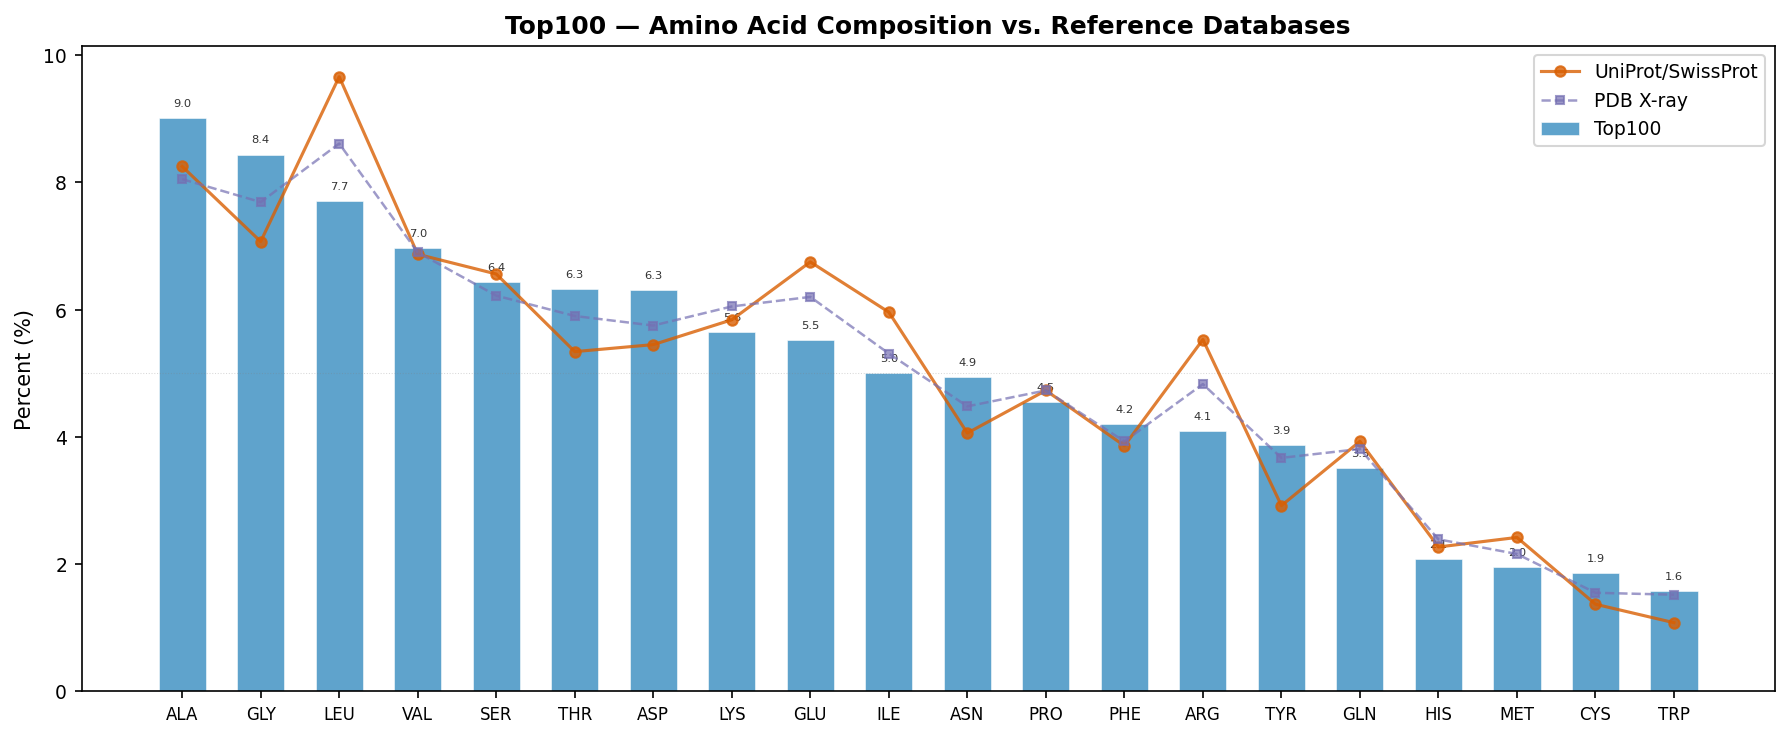

Residue     Count  Dataset%  UniProt%      PDB%  Δ UniProt
-------- -------- --------- --------- --------- ----------
ALA         1,570     9.01%     8.25%     8.05%     +0.76%
GLY         1,471     8.44%     7.07%     7.69%     +1.37%
LEU         1,343     7.70%     9.66%     8.61%     -1.96%
VAL         1,215     6.97%     6.87%     6.90%     +0.10%
SER         1,122     6.44%     6.56%     6.22%     -0.12%
THR         1,102     6.32%     5.34%     5.90%     +0.98%
ASP         1,099     6.30%     5.45%     5.75%     +0.85%
LYS           985     5.65%     5.84%     6.05%     -0.19%
GLU           963     5.52%     6.75%     6.20%     -1.23%
ILE           872     5.00%     5.96%     5.31%     -0.96%
ASN           862     4.94%     4.06%     4.48%     +0.88%
PRO           792     4.54%     4.73%     4.73%     -0.19%
PHE           732     4.20%     3.86%     3.93%     +0.34%
ARG           714     4.10%     5.53%     4.83%     -1.43%
TYR           676     3.88%     2.92%     3.67%     +0.9

In [5]:
# Amino acid composition with UniProt and PDB reference frequencies
NONSTANDARD_MAPPING = {"MSE": "MET"}

# Reference frequencies (%)
# UniProt/SwissProt ~2024 release (web.expasy.org/protscale/pscale/A.A.Swiss-Prot.html)
UNIPROT_PCT = {
    "ALA": 8.25, "ARG": 5.53, "ASN": 4.06, "ASP": 5.45, "CYS": 1.37,
    "GLN": 3.93, "GLU": 6.75, "GLY": 7.07, "HIS": 2.27, "ILE": 5.96,
    "LEU": 9.66, "LYS": 5.84, "MET": 2.42, "PHE": 3.86, "PRO": 4.73,
    "SER": 6.56, "THR": 5.34, "TRP": 1.08, "TYR": 2.92, "VAL": 6.87,
}

# PDB X-ray structures (~2025, 10K-entity sample via RCSB API, 2.49M residues)
PDB_XRAY_PCT = {
    "ALA": 8.05, "ARG": 4.83, "ASN": 4.48, "ASP": 5.75, "CYS": 1.55,
    "GLN": 3.81, "GLU": 6.20, "GLY": 7.69, "HIS": 2.39, "ILE": 5.31,
    "LEU": 8.61, "LYS": 6.05, "MET": 2.16, "PHE": 3.93, "PRO": 4.73,
    "SER": 6.22, "THR": 5.90, "TRP": 1.52, "TYR": 3.67, "VAL": 6.90,
}

resname_counts = Counter()
for r in records:
    rn = r["resname"]
    rn = NONSTANDARD_MAPPING.get(rn, rn)
    resname_counts[rn] += 1

# Sort by dataset count descending
sorted_aa = resname_counts.most_common()
names = [aa for aa, _ in sorted_aa]
counts_aa = [c for _, c in sorted_aa]
total = sum(counts_aa)
pcts = [100 * c / total for c in counts_aa]

# Reference values in same order
uniprot_vals = [UNIPROT_PCT.get(aa, 0) for aa in names]
pdb_vals = [PDB_XRAY_PCT.get(aa, 0) for aa in names]

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(names))

# Dataset as bars
bars = ax.bar(x, pcts, 0.6, color="#4393c3", alpha=0.85, label=f"{DATASET_NAME}",
              edgecolor="white", linewidth=0.3)

# Reference databases as lines with markers
ax.plot(x, uniprot_vals, "o-", color="#d95f02", markersize=5, linewidth=1.5,
        alpha=0.8, label="UniProt/SwissProt", zorder=5)
ax.plot(x, pdb_vals, "s--", color="#7570b3", markersize=4, linewidth=1.2,
        alpha=0.7, label="PDB X-ray", zorder=5)

# Annotate dataset bars with percentage
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f"{pct:.1f}", ha="center", va="bottom", fontsize=5.5, color="#333")

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel("Percent (%)", fontsize=10)
ax.set_title(f"{DATASET_NAME} — Amino Acid Composition vs. Reference Databases",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.axhline(5.0, color="gray", linewidth=0.5, linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

# Print comparison table
print(f"{'Residue':<8s} {'Count':>8s} {'Dataset%':>9s} {'UniProt%':>9s} {'PDB%':>9s} {'Δ UniProt':>10s}")
print(f"{'-'*8:<8s} {'-'*8:>8s} {'-'*9:>9s} {'-'*9:>9s} {'-'*9:>9s} {'-'*10:>10s}")
for aa, c in sorted_aa:
    dp = 100 * c / total
    up = UNIPROT_PCT.get(aa, 0)
    pp = PDB_XRAY_PCT.get(aa, 0)
    delta = dp - up
    print(f"{aa:<8s} {c:>8,} {dp:>8.2f}% {up:>8.2f}% {pp:>8.2f}% {delta:>+9.2f}%")

In [6]:
# Interpretive text for amino acid composition
display(Markdown(f"""### Representativeness of Amino Acid Composition

The table above compares the {DATASET_NAME} amino acid frequencies against two reference
databases:

- **UniProt/SwissProt** (~2024): amino acid frequencies across all reviewed protein sequences,
  representing the broadest available view of protein sequence space.
- **PDB X-ray** (~2025): frequencies from a 10,000-entity sample of X-ray crystallographic
  structures in the RCSB Protein Data Bank.

The two reference distributions are highly similar (most amino acids differ by <0.5%),
indicating that the PDB's well-known crystallization bias — overrepresentation of soluble,
globular, well-expressing proteins from model organisms — has only a modest effect on
overall amino acid composition. The largest reference-to-reference differences are:
Leu (9.66% UniProt vs 8.61% PDB, reflecting underrepresentation of membrane proteins),
Gly (7.07% vs 7.69%, reflecting enrichment of compact folds with tight turns), and
Arg (5.53% vs 4.83%, flexible sidechains harder to resolve crystallographically).

The {DATASET_NAME} dataset ({total:,} residues from {len(set(r['file'] for r in records)):,}
structures) shows additional deviations from both references due to:

1. **Quality filtering** — high-resolution, low-B-factor selection favors well-ordered regions
   and stable folds, which can shift composition toward residues prevalent in secondary
   structure cores (Ala, Val) and away from surface-exposed flexible residues (Arg, Lys, Glu).
2. **Homology reduction** — filtering to ≤70% sequence identity reduces redundancy toward
   more uniform sampling of fold space, which can shift composition away from overrepresented
   protein families.
3. **Sample size** — with {len(set(r['file'] for r in records)):,} structures, sampling variance
   is appreciable. The larger top2018 datasets (11,000+ structures) converge substantially
   closer to the PDB reference.

The Δ UniProt column quantifies the per-residue deviation from the sequence universe baseline.
"""))

### Representativeness of Amino Acid Composition

The table above compares the Top100 amino acid frequencies against two reference
databases:

- **UniProt/SwissProt** (~2024): amino acid frequencies across all reviewed protein sequences,
  representing the broadest available view of protein sequence space.
- **PDB X-ray** (~2025): frequencies from a 10,000-entity sample of X-ray crystallographic
  structures in the RCSB Protein Data Bank.

The two reference distributions are highly similar (most amino acids differ by <0.5%),
indicating that the PDB's well-known crystallization bias — overrepresentation of soluble,
globular, well-expressing proteins from model organisms — has only a modest effect on
overall amino acid composition. The largest reference-to-reference differences are:
Leu (9.66% UniProt vs 8.61% PDB, reflecting underrepresentation of membrane proteins),
Gly (7.07% vs 7.69%, reflecting enrichment of compact folds with tight turns), and
Arg (5.53% vs 4.83%, flexible sidechains harder to resolve crystallographically).

The Top100 dataset (17,434 residues from 98
structures) shows additional deviations from both references due to:

1. **Quality filtering** — high-resolution, low-B-factor selection favors well-ordered regions
   and stable folds, which can shift composition toward residues prevalent in secondary
   structure cores (Ala, Val) and away from surface-exposed flexible residues (Arg, Lys, Glu).
2. **Homology reduction** — filtering to ≤70% sequence identity reduces redundancy toward
   more uniform sampling of fold space, which can shift composition away from overrepresented
   protein families.
3. **Sample size** — with 98 structures, sampling variance
   is appreciable. The larger top2018 datasets (11,000+ structures) converge substantially
   closer to the PDB reference.

The Δ UniProt column quantifies the per-residue deviation from the sequence universe baseline.


## Chain Length Distribution

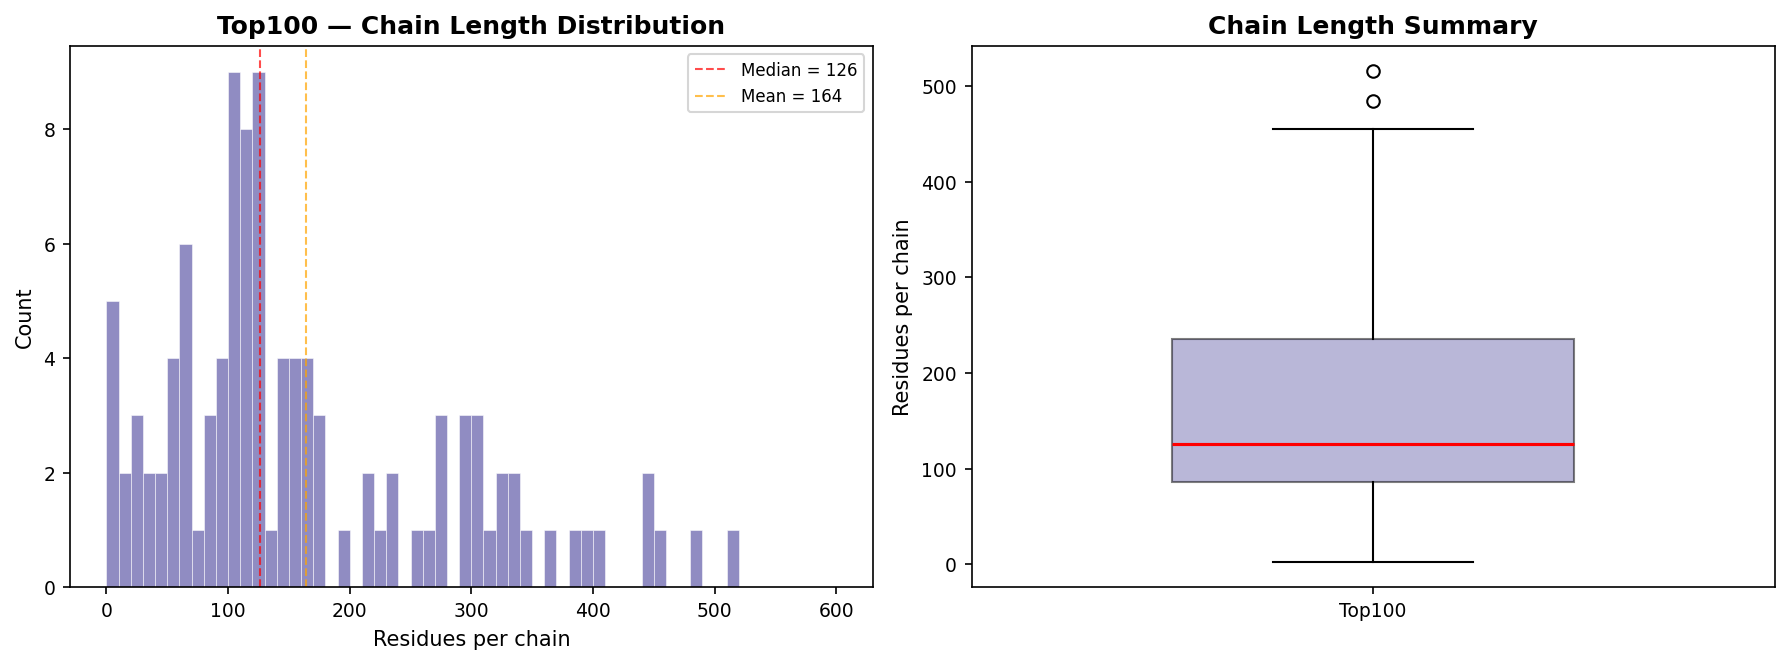

Chain length statistics (106 chains):
  Min:             2
  Q1:             86
  Median:        126
  Mean:        164.5
  Q3:            235
  Max:           516
  Std:         119.8


In [7]:
# Chain length distribution
from collections import defaultdict

chain_lengths = defaultdict(int)
for r in records:
    key = (r["file"], r.get("chain", ""))
    chain_lengths[key] += 1

lengths = np.array(list(chain_lengths.values()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Histogram
ax1.hist(lengths, bins=60, range=(0, max(600, np.percentile(lengths, 99))),
         color="#7570b3", alpha=0.8, edgecolor="white", linewidth=0.3)
ax1.axvline(np.median(lengths), color="red", linewidth=1, linestyle="--",
            alpha=0.7, label=f"Median = {np.median(lengths):.0f}")
ax1.axvline(np.mean(lengths), color="orange", linewidth=1, linestyle="--",
            alpha=0.7, label=f"Mean = {np.mean(lengths):.0f}")
ax1.set_xlabel("Residues per chain", fontsize=10)
ax1.set_ylabel("Count", fontsize=10)
ax1.set_title(f"{DATASET_NAME} — Chain Length Distribution", fontsize=12, fontweight="bold")
ax1.legend(fontsize=8)

# Box plot
ax2.boxplot(lengths, vert=True, widths=0.5,
            patch_artist=True,
            boxprops=dict(facecolor="#7570b3", alpha=0.5),
            medianprops=dict(color="red", linewidth=1.5))
ax2.set_ylabel("Residues per chain", fontsize=10)
ax2.set_title("Chain Length Summary", fontsize=12, fontweight="bold")
ax2.set_xticklabels([DATASET_NAME])

plt.tight_layout()
plt.show()

# Summary statistics
print(f"Chain length statistics ({len(lengths):,} chains):")
print(f"  Min:      {lengths.min():>8,}")
print(f"  Q1:       {np.percentile(lengths, 25):>8.0f}")
print(f"  Median:   {np.median(lengths):>8.0f}")
print(f"  Mean:     {np.mean(lengths):>8.1f}")
print(f"  Q3:       {np.percentile(lengths, 75):>8.0f}")
print(f"  Max:      {lengths.max():>8,}")
print(f"  Std:      {np.std(lengths):>8.1f}")

In [8]:
def rose_plot(ax, angles_deg, n_bins=36, title="", color="steelblue", alpha=0.8):
    """Draw a rose plot (circular histogram) on a polar axes.
    
    Angles are in degrees (-180 to 180). Bins are evenly spaced around
    the full circle. Bar height is proportional to count.
    """
    bin_width = 2 * np.pi / n_bins
    # Convert to radians, shift to [0, 2pi)
    rads = np.deg2rad(angles_deg) % (2 * np.pi)
    bins = np.linspace(0, 2 * np.pi, n_bins + 1)
    counts, _ = np.histogram(rads, bins=bins)
    
    # Plot bars centered on bin midpoints
    midpoints = (bins[:-1] + bins[1:]) / 2
    bars = ax.bar(midpoints, counts, width=bin_width, bottom=0,
                  color=color, alpha=alpha, edgecolor="white", linewidth=0.3)
    
    # Label in degrees: 0, 90, 180/-180, -90
    ax.set_xticks(np.deg2rad([0, 60, 120, 180, 240, 300]))
    ax.set_xticklabels(["0°", "60°", "120°", "±180°", "-120°", "-60°"])
    ax.set_theta_zero_location("N")  # 0° at top
    ax.set_theta_direction(-1)  # clockwise
    ax.set_title(title, pad=15, fontweight="bold")
    
    # Circular mean and std annotation
    s = np.sum(np.sin(np.deg2rad(angles_deg)))
    c = np.sum(np.cos(np.deg2rad(angles_deg)))
    n = len(angles_deg)
    circ_mean = np.degrees(np.arctan2(s / n, c / n))
    R = np.sqrt((s / n)**2 + (c / n)**2)
    circ_std = np.degrees(np.sqrt(-2 * np.log(R))) if R > 1e-15 else 180.0
    ax.annotate(f"mean={circ_mean:.1f}°\nstd={circ_std:.1f}°\nn={n:,}",
                xy=(0.02, 0.98), xycoords="axes fraction",
                fontsize=7, va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    return bars

## Backbone Torsion Angles — Rose Plots

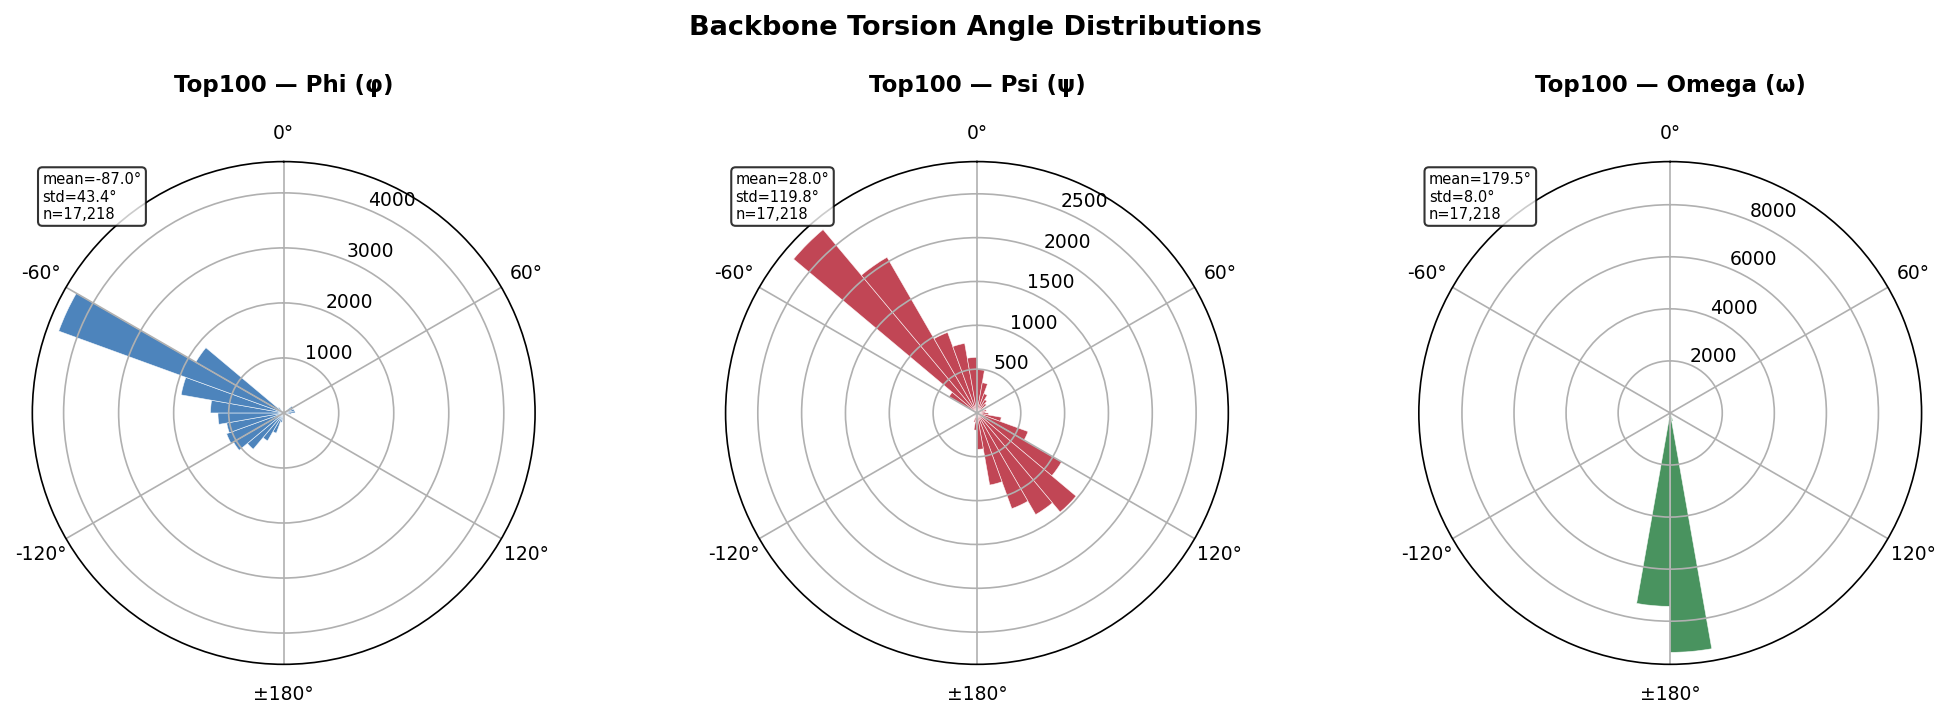

In [9]:
fig, axes = plt.subplots(1, 3, subplot_kw={"projection": "polar"}, figsize=(14, 4.5))

rose_plot(axes[0], phi, title=f"{DATASET_NAME} — Phi (φ)", color="#2166ac")
rose_plot(axes[1], psi, title=f"{DATASET_NAME} — Psi (ψ)", color="#b2182b")
rose_plot(axes[2], omega, title=f"{DATASET_NAME} — Omega (ω)", color="#1b7837")

fig.suptitle("Backbone Torsion Angle Distributions", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Sidechain Torsion Angles — Rose Plots

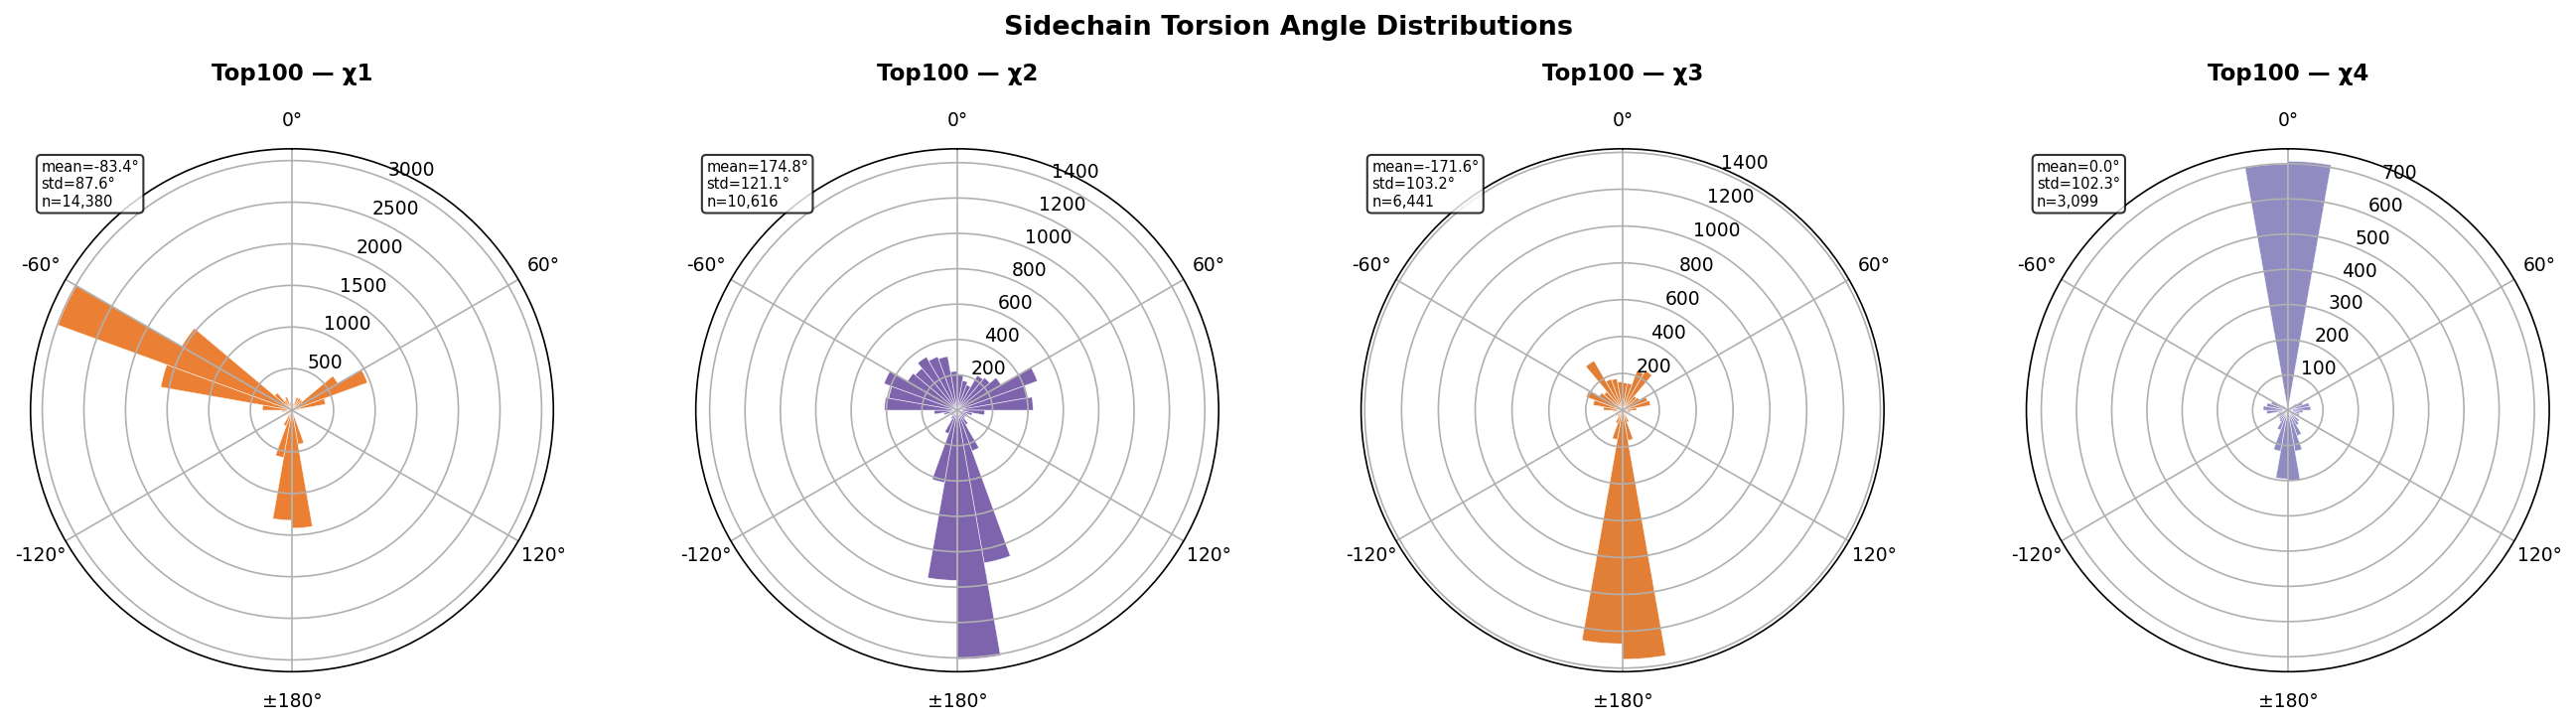

In [10]:
n_chi = len(chi)
if n_chi > 0:
    chi_colors = ["#e66101", "#5e3c99", "#d95f02", "#7570b3"]
    fig, axes = plt.subplots(1, n_chi, subplot_kw={"projection": "polar"},
                             figsize=(4.5 * n_chi, 4.5))
    if n_chi == 1:
        axes = [axes]
    for i, (field, values) in enumerate(chi.items()):
        label = field.replace("chi", "χ")
        rose_plot(axes[i], values, title=f"{DATASET_NAME} — {label}",
                  color=chi_colors[i % len(chi_colors)])
    fig.suptitle("Sidechain Torsion Angle Distributions", fontsize=13,
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No chi angle data available in this dataset.")

## Ramachandran Plots by Category

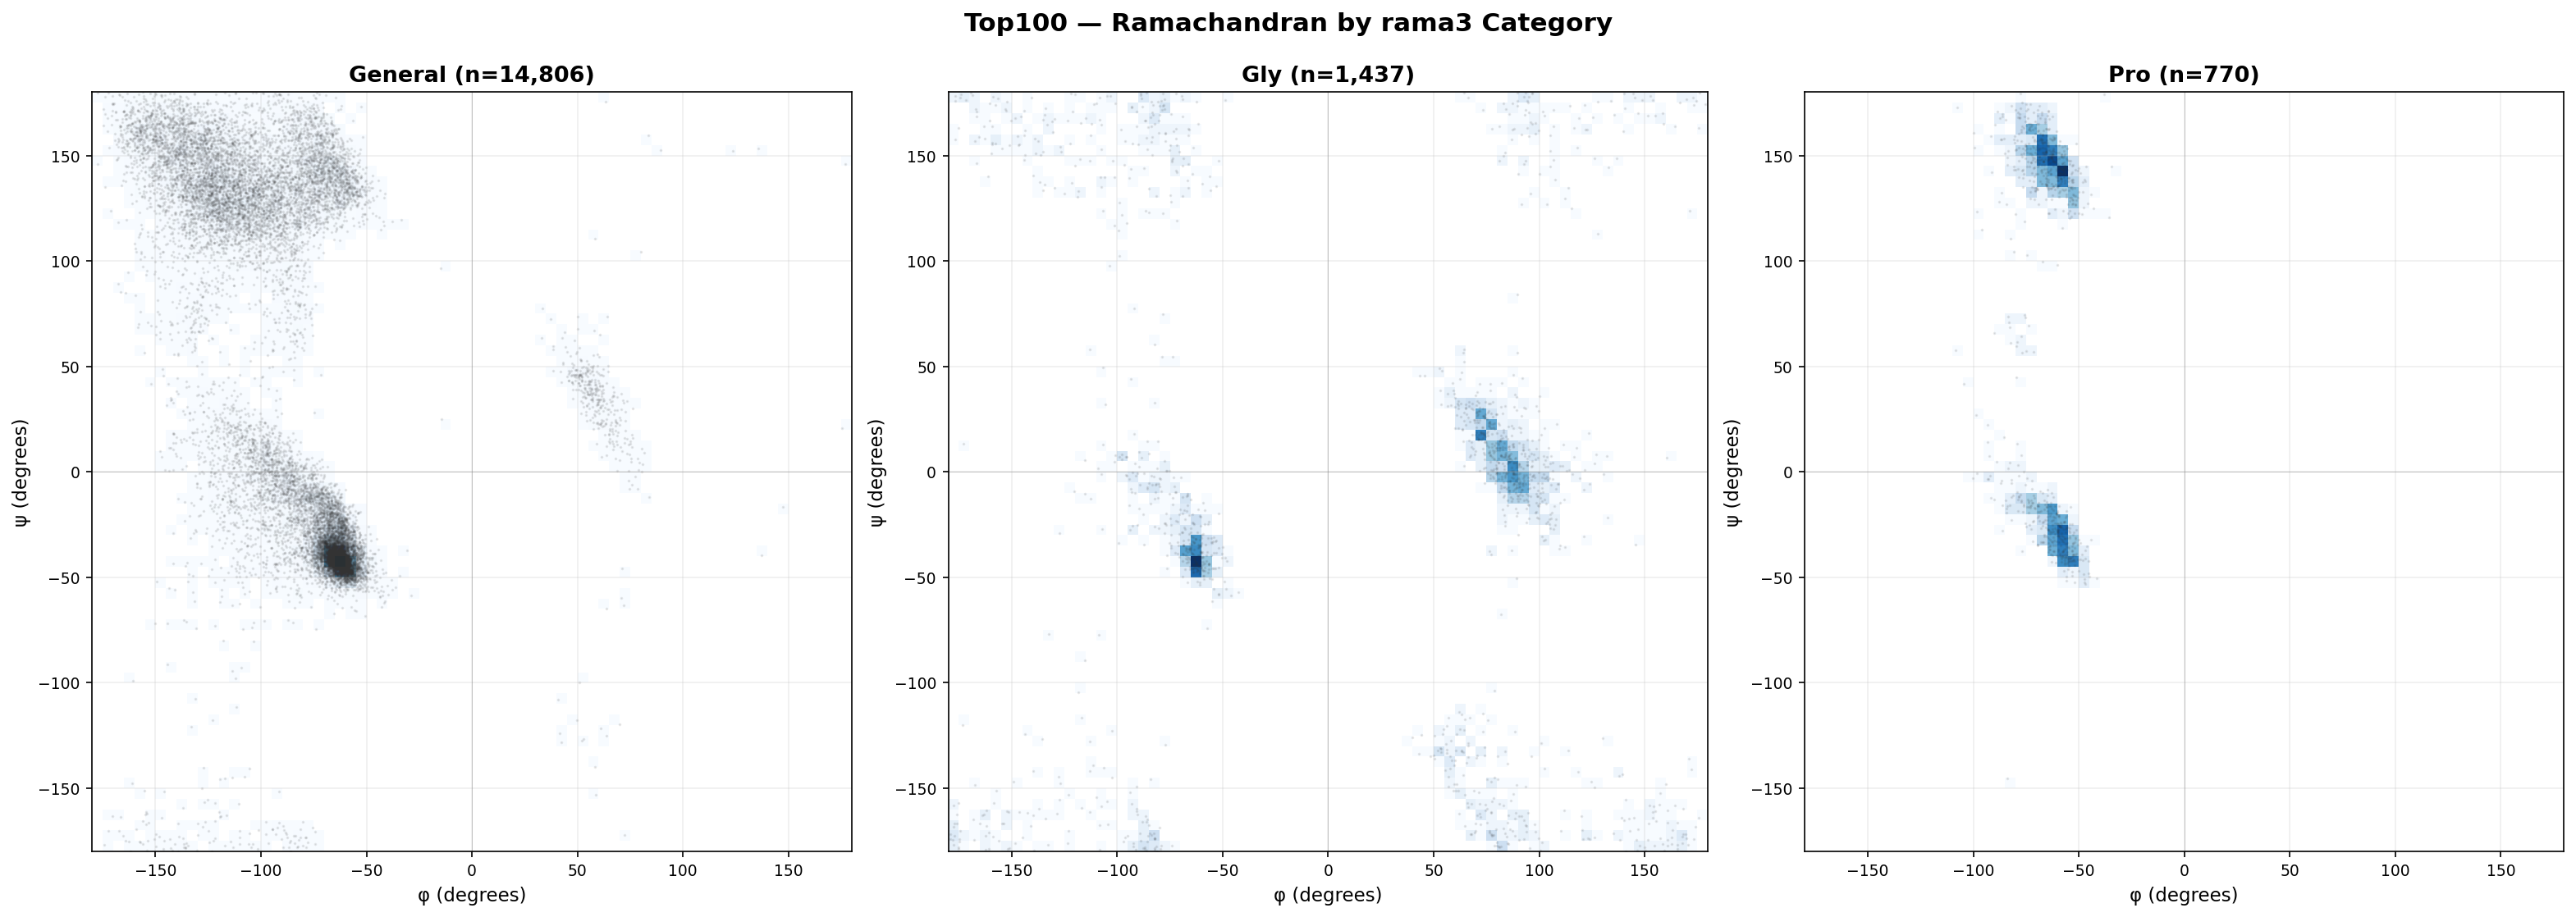


Category counts (rama3):
  General        14,806  (84.93%)
  Gly             1,437  ( 8.24%)
  Pro               770  ( 4.42%)


In [11]:
# Per-category Ramachandran plots using the selected RAMA_FIELD
rama_cat_counts = Counter(r.get(RAMA_FIELD) for r in records if r.get(RAMA_FIELD) is not None)
categories = [cat for cat, _ in rama_cat_counts.most_common()]

n_cats = len(categories)

# One row of equal-sized square plots, sized generously
fig_width = 7 * n_cats
fig_height = 7
fig, axes = plt.subplots(1, n_cats, figsize=(fig_width, fig_height))
if n_cats == 1:
    axes = [axes]

for idx, cat in enumerate(categories):
    ax = axes[idx]
    
    cat_records = [(r["phi"], r["psi"]) for r in records
                   if r.get(RAMA_FIELD) == cat
                   and r.get("phi") is not None
                   and r.get("psi") is not None]
    
    if cat_records:
        ph, ps = zip(*cat_records)
        
        # 2D histogram (density)
        h = ax.hist2d(ph, ps, bins=72, range=[[-180, 180], [-180, 180]],
                      cmap="Blues", cmin=1)
        
        # Scatter overlay for sparse regions
        ax.scatter(ph, ps, s=0.5, alpha=0.1, c="#333333", rasterized=True)
    
    ax.set_xlim(-180, 180)
    ax.set_ylim(-180, 180)
    ax.set_xlabel("φ (degrees)", fontsize=11)
    ax.set_ylabel("ψ (degrees)", fontsize=11)
    n_cat = rama_cat_counts[cat]
    ax.set_title(f"{cat} (n={n_cat:,})", fontsize=13, fontweight="bold")
    ax.set_aspect("equal")
    ax.axhline(0, color="gray", linewidth=0.4, alpha=0.5)
    ax.axvline(0, color="gray", linewidth=0.4, alpha=0.5)
    ax.grid(True, alpha=0.2)

fig.suptitle(f"{DATASET_NAME} — Ramachandran by {RAMA_FIELD} Category",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nCategory counts ({RAMA_FIELD}):")
for cat, n in rama_cat_counts.most_common():
    print(f"  {cat:<12s} {n:>8,}  ({100*n/len(records):5.2f}%)")

## Tau (N-Cα-C Bond Angle) Distribution

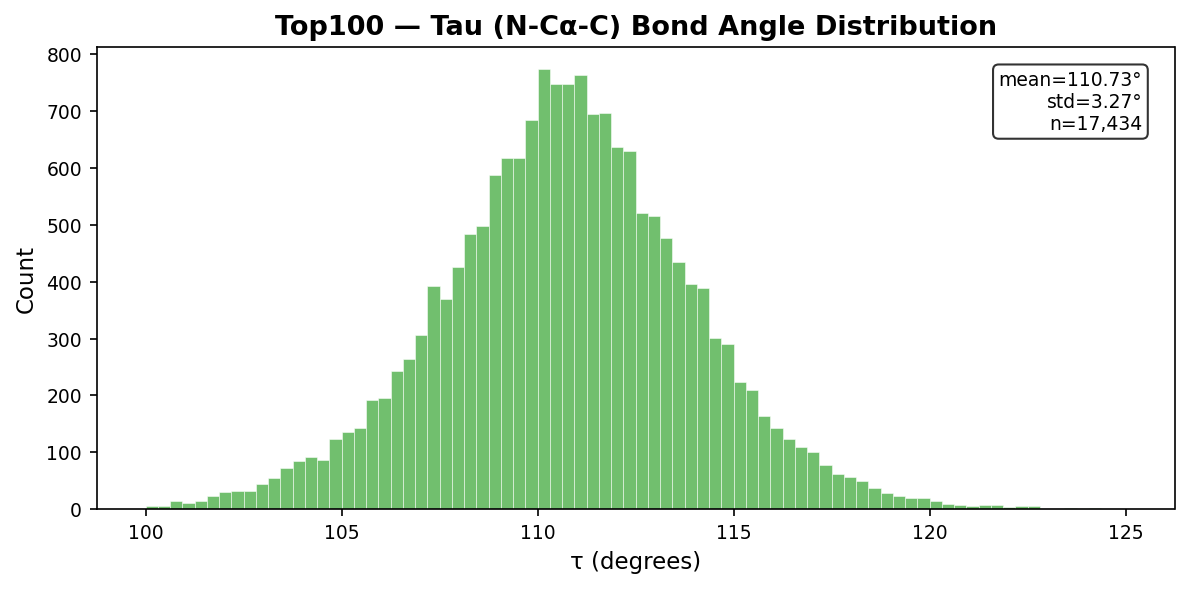

In [12]:
# Tau is a bond angle (not periodic), so use a linear histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(tau, bins=80, range=(100, 125), color="#4daf4a", alpha=0.8,
        edgecolor="white", linewidth=0.3)
ax.set_xlabel("τ (degrees)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(f"{DATASET_NAME} — Tau (N-Cα-C) Bond Angle Distribution",
             fontsize=13, fontweight="bold")
ax.annotate(f"mean={tau.mean():.2f}°\nstd={tau.std():.2f}°\nn={len(tau):,}",
            xy=(0.97, 0.95), xycoords="axes fraction", fontsize=9,
            va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
plt.tight_layout()
plt.show()

## Omega Deviation from Planarity (Trans Peptides Only)

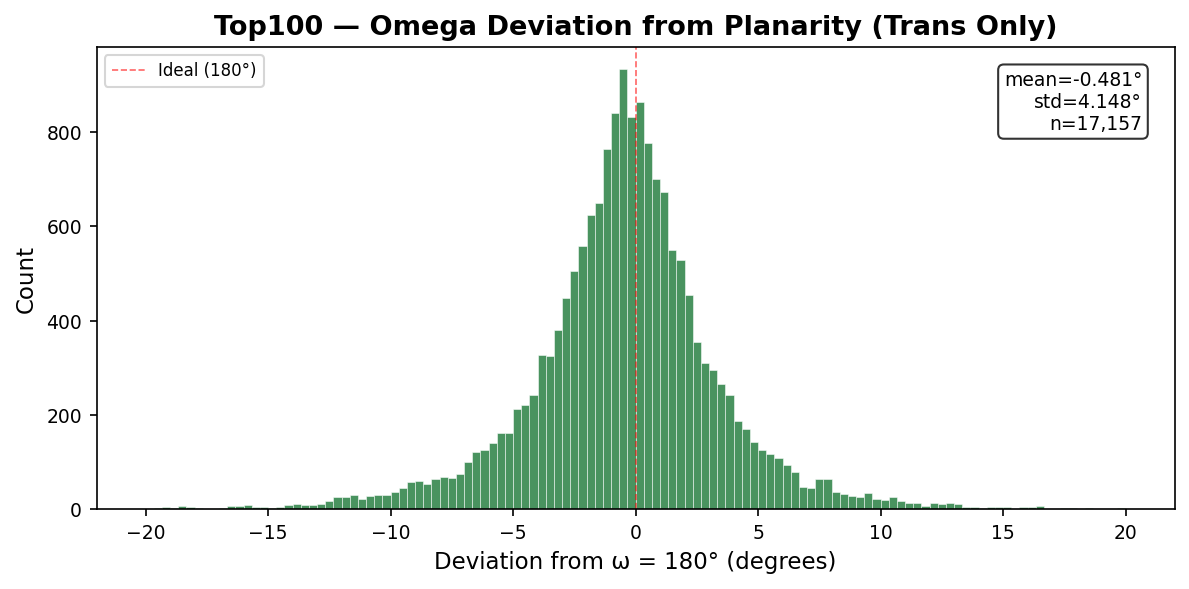

In [13]:
# Omega deviation from planarity — SIGNED (positive = beyond 180°, negative = below)
omega_dev = []
for r in records:
    o = r.get("omega")
    if o is None:
        continue
    # Support both field conventions
    pb = r.get("peptide_bond")
    cis = r.get("is_cis")
    if pb is not None:
        is_trans = (pb == "trans")
    elif cis is not None:
        is_trans = (cis == "False") if isinstance(cis, str) else (not cis)
    else:
        is_trans = True
    if is_trans:
        # Signed deviation: map omega to deviation from 180°
        # omega=175 → -5, omega=-175 (=185°) → +5
        dev = (o % 360) - 180
        omega_dev.append(dev)

omega_dev = np.array(omega_dev)

fig, ax = plt.subplots(figsize=(8, 4))
if len(omega_dev) > 0:
    ax.hist(omega_dev, bins=120, range=(-20, 20), color="#1b7837", alpha=0.8,
            edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="red", linewidth=0.8, linestyle="--", alpha=0.6, label="Ideal (180°)")
    circ_mean = np.degrees(np.arctan2(np.sin(np.deg2rad(omega_dev)).mean(),
                                       np.cos(np.deg2rad(omega_dev)).mean()))
    ax.annotate(f"mean={omega_dev.mean():.3f}°\nstd={omega_dev.std():.3f}°\nn={len(omega_dev):,}",
                xy=(0.97, 0.95), xycoords="axes fraction", fontsize=9,
                va="top", ha="right",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.legend(fontsize=8)
ax.set_xlabel("Deviation from ω = 180° (degrees)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(f"{DATASET_NAME} — Omega Deviation from Planarity (Trans Only)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary Statistics

In [14]:
# Dataset overview
files = set(r["file"] for r in records)
chains = set((r["file"], r.get("chain", "")) for r in records)
rama_counts = Counter(r.get("rama_category") for r in records if r.get("rama_category"))

print(f"{'Dataset:':<25s} {DATASET_NAME}")
print(f"{'Total residues:':<25s} {len(records):,}")
print(f"{'Unique structures:':<25s} {len(files):,}")
print(f"{'Unique chains:':<25s} {len(chains):,}")
print()
print("Ramachandran category distribution:")
for cat, n in rama_counts.most_common():
    print(f"  {cat:<12s} {n:>8,}  ({100*n/len(records):5.2f}%)")
print()

# Circular stats for all torsion angles
def circ_stats(angles):
    n = len(angles)
    s = np.sum(np.sin(np.deg2rad(angles)))
    c = np.sum(np.cos(np.deg2rad(angles)))
    mean = np.degrees(np.arctan2(s / n, c / n))
    R = np.sqrt((s / n)**2 + (c / n)**2)
    std = np.degrees(np.sqrt(-2 * np.log(R))) if R > 1e-15 else 180.0
    return mean, std, n

print(f"{'Angle':<8s} {'N':>10s} {'Circ Mean':>12s} {'Circ Std':>12s}")
print(f"{'-'*8:<8s} {'-'*10:>10s} {'-'*12:>12s} {'-'*12:>12s}")
for name, vals in [("phi", phi), ("psi", psi), ("omega", omega)]:
    m, s, n = circ_stats(vals)
    print(f"{name:<8s} {n:>10,} {m:>12.3f} {s:>12.3f}")
# Tau is linear
print(f"{'tau':<8s} {len(tau):>10,} {tau.mean():>12.3f} {tau.std():>12.3f}")
for name, vals in chi.items():
    m, s, n = circ_stats(vals)
    print(f"{name:<8s} {n:>10,} {m:>12.3f} {s:>12.3f}")

Dataset:                  Top100
Total residues:           17,434
Unique structures:        98
Unique chains:            106

Ramachandran category distribution:
  General        12,187  (69.90%)
  IleVal          2,052  (11.77%)
  Gly             1,437  ( 8.24%)
  TransPro          720  ( 4.13%)
  PrePro            567  ( 3.25%)
  CisPro             50  ( 0.29%)

Angle             N    Circ Mean     Circ Std
-------- ---------- ------------ ------------
phi          17,218      -86.970       43.398
psi          17,218       27.990      119.824
omega        17,218      179.521        7.966
tau          17,434      110.729        3.269
chi1         14,380      -83.355       87.557
chi2         10,616      174.761      121.133
chi3          6,441     -171.584      103.209
chi4          3,099        0.024      102.314
